# Homogeneous Measurements, Control Charts, and Order Statistics

This notebook is a step-by-step tutorial for the main ideas in Chapter 5:

1. What it means for measurements to be *homogeneous*
2. Why mixing cold and warm benchmark results is usually wrong
3. How Shewhart-style control charts detect non-homogeneity
4. What order statistics are
5. Why expected probability area is not the same as expected x-axis position
6. How normal probability plots / Q-Q plots work
7. How to compare normal vs exponential assumptions
8. How this applies to benchmark data, such as cold vs warmed randwrite

The examples are intentionally small and explicit.

## 0. Setup

We will use only standard scientific Python libraries.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statistics import NormalDist

rng = np.random.default_rng(12345)

normal = NormalDist()

def norm_ppf(p):
    """Inverse CDF of standard normal distribution."""
    return normal.inv_cdf(float(p))

def exp_ppf(p, rate=1.0):
    """Inverse CDF of exponential distribution with given rate."""
    return -math.log(1.0 - p) / rate

## 1. The problem: are repeated measurements really comparable?

Suppose we measure the same thing many times. A tempting workflow is:

1. collect many numbers;
2. compute their average;
3. compute their standard deviation;
4. compare averages before and after a change.

But this only makes sense if the numbers are plausibly from the same measurement population.

A *homogeneous set* means the observations behave like repeated draws from one stable process.

For example, these two benchmark procedures are probably **not** the same population:

```text
cold randwrite:
    start VM
    immediately run randwrite

read-warmed randwrite:
    start VM
    run randread
    then run randwrite
```

If the first gives 70 MiB/s and the second gives 500 MiB/s, they should not be averaged together as "randwrite performance".

In [2]:
cold = rng.normal(loc=70, scale=8, size=12)
warm = rng.normal(loc=500, scale=30, size=12)
mixed = np.concatenate([cold, warm])

df = pd.DataFrame({
    "run": np.arange(1, len(mixed) + 1),
    "throughput_mib_s": mixed,
    "condition": ["cold"] * len(cold) + ["read-warmed"] * len(warm),
})
df

,run,throughput_mib_s,condition
0,1,58.609400,cold
1,2,80.109828,cold
2,3,63.034706,cold
3,4,67.926614,cold
4,5,69.397254,cold
5,6,64.072923,cold
6,7,59.057658,cold
7,8,75.191142,cold
8,9,72.888465,cold
9,10,54.377095,cold


The two groups have very different centers. If we average them together, the result is not representative of either scenario.

In [3]:
summary = df.groupby("condition")["throughput_mib_s"].agg(["count", "mean", "std"])
mixed_summary = pd.DataFrame({
    "count": [len(mixed)],
    "mean": [mixed.mean()],
    "std": [mixed.std(ddof=1)]
}, index=["mixed"])
pd.concat([summary, mixed_summary])

,count,mean,std
cold,12,69.266028,10.115655
read-warmed,12,503.565293,30.293390
mixed,24,286.415661,222.916955


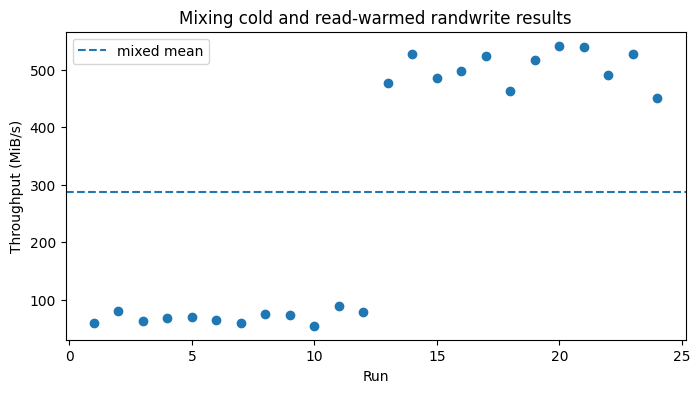

In [4]:
plt.figure(figsize=(8, 4))
plt.scatter(df["run"], df["throughput_mib_s"])
plt.axhline(mixed.mean(), linestyle="--", label="mixed mean")
plt.xlabel("Run")
plt.ylabel("Throughput (MiB/s)")
plt.title("Mixing cold and read-warmed randwrite results")
plt.legend()
plt.show()

The dashed line is the mixed average. It is neither a cold-state result nor a warm-state result.

This is the main lesson: **warming is part of the experimental condition**.

## 2. Homogeneous vs non-homogeneous measurements

Let's simulate two cases:

1. A homogeneous process: one stable mean.
2. A drifting process: mean changes over time.

Both can have randomness, but only the first is safe to summarize as one stable population.

In [5]:
n = 40

homogeneous = rng.normal(loc=100, scale=5, size=n)
drifting = 100 + np.linspace(0, 30, n) + rng.normal(loc=0, scale=5, size=n)

df2 = pd.DataFrame({
    "run": np.arange(1, n + 1),
    "homogeneous": homogeneous,
    "drifting": drifting,
})
df2.head()

,run,homogeneous,drifting
0,1,99.209054,91.797911
1,2,102.247420,96.482937
2,3,93.281995,104.979870
3,4,99.591562,96.535044
4,5,108.623700,106.329185


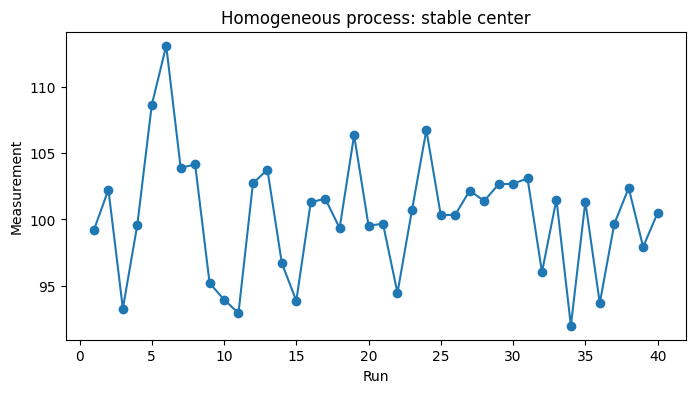

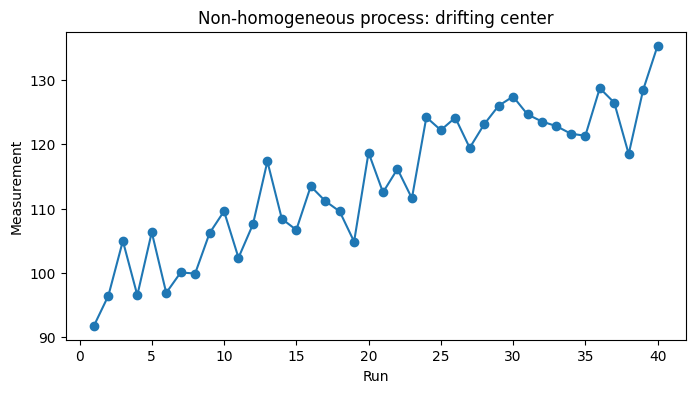

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(df2["run"], df2["homogeneous"], marker="o")
plt.xlabel("Run")
plt.ylabel("Measurement")
plt.title("Homogeneous process: stable center")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(df2["run"], df2["drifting"], marker="o")
plt.xlabel("Run")
plt.ylabel("Measurement")
plt.title("Non-homogeneous process: drifting center")
plt.show()

The drifting series is not just "noisier." It has a systematic time pattern. A single average would hide that.

## 3. Control chart idea

The chapter's control chart idea is:

> Divide observations into small rational subgroups, then compare variation between subgroup averages with variation within subgroups.

For a chronological benchmark, a natural subgroup might be consecutive runs.

For example, with subgroup size 4:

```text
group 1: runs 1-4
group 2: runs 5-8
group 3: runs 9-12
...
```

For each subgroup:

- compute the subgroup average;
- compute the subgroup range: max - min.

The average range estimates short-term variability.

In [7]:
def subgroup_table(values, group_size):
    values = np.asarray(values)
    k = len(values) // group_size
    trimmed = values[:k * group_size]
    groups = trimmed.reshape(k, group_size)
    rows = []
    for i, g in enumerate(groups, start=1):
        rows.append({
            "subgroup": i,
            "mean": g.mean(),
            "range": g.max() - g.min(),
            "values": list(np.round(g, 2)),
        })
    return pd.DataFrame(rows)

hom_groups = subgroup_table(homogeneous, group_size=4)
drift_groups = subgroup_table(drifting, group_size=4)

hom_groups

,subgroup,mean,range,values
0,1,98.582508,8.965425,"[99.21, 102.25, 93.28, 99.59]"
1,2,107.436117,9.203990,"[108.62, 113.09, 103.89, 104.14]"
2,3,96.201098,9.769194,"[95.21, 93.95, 92.94, 102.71]"
3,4,98.902577,9.903072,"[103.76, 96.71, 93.86, 101.29]"
4,5,101.698890,7.003974,"[101.56, 99.35, 106.35, 99.54]"
5,6,100.385837,12.276461,"[99.67, 94.46, 100.68, 106.74]"
6,7,101.053996,1.862553,"[100.31, 100.35, 102.17, 101.39]"
7,8,101.112882,7.066837,"[102.65, 102.68, 103.09, 96.02]"
8,9,97.128131,9.513663,"[101.5, 91.99, 101.33, 93.69]"
9,10,100.107052,4.444517,"[99.64, 102.37, 97.93, 100.49]"


### 3.1 Estimate sigma from subgroup ranges

For subgroup size 4, a common control-chart constant is:

$$
d_2 \approx 2.059
$$

The average subgroup range $\bar{R}$ estimates the individual-observation standard deviation by:

$$
\hat{\sigma} \approx \frac{\bar{R}}{d_2}
$$

The standard deviation of subgroup means is then:

$$
\hat{\sigma}_{\bar{x}} \approx \frac{\hat{\sigma}}{\sqrt{m}}
$$

where $m$ is subgroup size.

This is the same style of calculation used in the chapter.

In [8]:
D2 = {
    2: 1.128,
    3: 1.693,
    4: 2.059,
    5: 2.326,
    6: 2.534,
}

def control_chart_stats(values, group_size=4, sigma_limits=2):
    tbl = subgroup_table(values, group_size)
    grand_mean = np.mean(values[:len(tbl) * group_size])
    rbar = tbl["range"].mean()
    sigma_hat = rbar / D2[group_size]
    sigma_mean_hat = sigma_hat / math.sqrt(group_size)
    lower = grand_mean - sigma_limits * sigma_mean_hat
    upper = grand_mean + sigma_limits * sigma_mean_hat
    return tbl, {
        "grand_mean": grand_mean,
        "Rbar": rbar,
        "sigma_hat": sigma_hat,
        "sigma_mean_hat": sigma_mean_hat,
        "lower": lower,
        "upper": upper,
    }

hom_tbl, hom_stats = control_chart_stats(homogeneous, group_size=4, sigma_limits=2)
drift_tbl, drift_stats = control_chart_stats(drifting, group_size=4, sigma_limits=2)

hom_stats, drift_stats

({'grand_mean': np.float64(100.26090874111857),
  'Rbar': np.float64(8.000968685305036),
  'sigma_hat': np.float64(3.8858517170009885),
  'sigma_mean_hat': np.float64(1.9429258585004943),
  'lower': np.float64(96.37505702411758),
  'upper': np.float64(104.14676045811956)},
 {'grand_mean': np.float64(114.17937079913597),
  'Rbar': np.float64(9.973126097817278),
  'sigma_hat': np.float64(4.843674646827235),
  'sigma_mean_hat': np.float64(2.4218373234136177),
  'lower': np.float64(109.33569615230873),
  'upper': np.float64(119.0230454459632)})

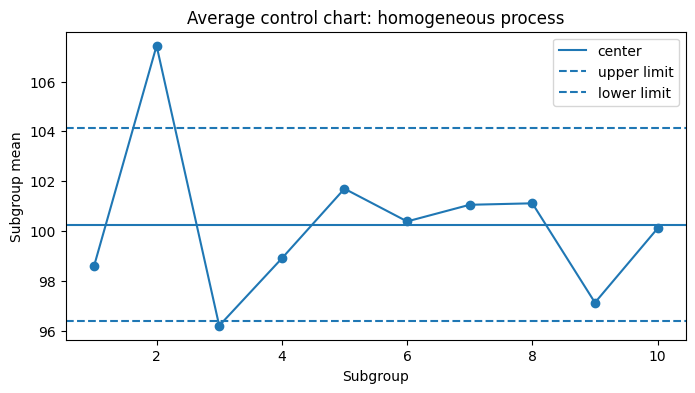

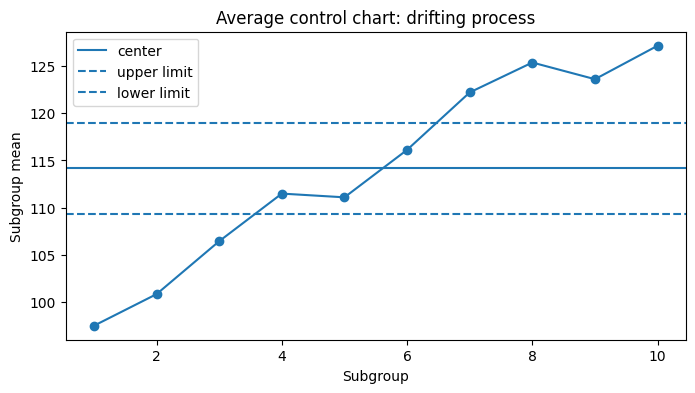

In [9]:
def plot_average_control_chart(tbl, stats, title):
    plt.figure(figsize=(8, 4))
    plt.plot(tbl["subgroup"], tbl["mean"], marker="o")
    plt.axhline(stats["grand_mean"], label="center")
    plt.axhline(stats["upper"], linestyle="--", label="upper limit")
    plt.axhline(stats["lower"], linestyle="--", label="lower limit")
    plt.xlabel("Subgroup")
    plt.ylabel("Subgroup mean")
    plt.title(title)
    plt.legend()
    plt.show()

plot_average_control_chart(hom_tbl, hom_stats, "Average control chart: homogeneous process")
plot_average_control_chart(drift_tbl, drift_stats, "Average control chart: drifting process")

The drifting process produces subgroup averages that move systematically. That is evidence against treating all observations as one homogeneous population.

For benchmark data, this is the same reason to avoid mixing:

- cold runs;
- warmed runs;
- runs before background fetch completes;
- runs after background fetch completes;
- runs with different VM placement or host state;
- runs before/after caches are populated.

## 4. Order statistics

Now assume we have already checked that the data are reasonably homogeneous.

The next question is:

> What does the measurement population look like?

For example:

- approximately normal?
- skewed?
- heavy-tailed?
- mixed from multiple populations?

Order statistics help with this.

Given observations:

$$
x_1, x_2, \ldots, x_N
$$

the order statistics are the sorted observations:

$$
x_{(1)} \le x_{(2)} \le \cdots \le x_{(N)}
$$

In [10]:
sample = np.array([5.12, 5.12, 5.02, 5.12, 4.98, 5.08, 4.95, 4.98, 5.03, 5.00,
                   5.02, 4.80, 4.97, 5.05, 5.04, 4.82, 5.01, 4.91, 5.22, 4.94])

ordered = np.sort(sample)

pd.DataFrame({
    "i": np.arange(1, len(sample) + 1),
    "original_y": sample,
    "ordered_y": ordered,
})

,i,original_y,ordered_y
0,1,5.12,4.80
1,2,5.12,4.82
2,3,5.02,4.91
3,4,5.12,4.94
4,5,4.98,4.95
5,6,5.08,4.97
6,7,4.95,4.98
7,8,4.98,4.98
8,9,5.03,5.00
9,10,5.00,5.01


The sorted values throw away time order. That is bad for detecting drift, but good for studying distributional shape.

## 5. Expected area vs expected x-position

This is the subtle point from the chapter.

For a sample of size \(N\), the sorted observations divide the probability area into \(N+1\) gaps.

For the \(i\)-th order statistic, the expected cumulative area to its left is:

$$
E[F(X_{(i)})] = \frac{i}{N+1}
$$

But the expected x-axis location is **not usually**:

$$
F^{-1}\left(\frac{i}{N+1}\right)
$$

because $F^{-1}$ is nonlinear.

In general:

$$
E[F^{-1}(U)] \ne F^{-1}(E[U])
$$

### 5.1 Concrete example: one exponential observation

Let $X$ be exponential with rate 1:

$$
F(x) = 1 - e^{-x}
$$

For $N=1$, the only order statistic is the observation itself.

The expected area to the left is:

$$
E[F(X)] = \frac{1}{2}
$$

The x-position corresponding to area $1/2$ is the median:

$$
F^{-1}(1/2) = \log 2 \approx 0.693
$$

But the expected x-position is:

$$
E[X] = 1
$$

So the two are different.

In [11]:
median_position = exp_ppf(0.5)
expected_x = 1.0

pd.DataFrame({
    "quantity": [
        "area-based x-position F^{-1}(1/2)",
        "expected x-position E[X]"
    ],
    "value": [median_position, expected_x]
})

,quantity,value
0,area-based x-position F^{-1}(1/2),0.693147
1,expected x-position E[X],1.000000


In [12]:
# Monte Carlo check
x = rng.exponential(scale=1.0, size=1_000_000)
u = 1 - np.exp(-x)

pd.DataFrame({
    "quantity": ["mean of F(X)", "F^{-1}(mean of F(X))", "mean of X"],
    "value": [u.mean(), exp_ppf(u.mean()), x.mean()]
})

,quantity,value
0,mean of F(X),0.500046
1,F^{-1}(mean of F(X)),0.693240
2,mean of X,1.000718


The simulation shows:

- the expected area is about 0.5;
- the x-position corresponding to area 0.5 is about 0.693;
- the expected x-position is about 1.0.

This is exactly the distinction the book is warning about.

### 5.2 Same issue for \(N=20\)

For $N=20$, the simple plotting position for the $i$-th order statistic is:

$$
\frac{i}{21}
$$

But the true expected x-position of $X_{(i)}$ is not exactly:

$$
F^{-1}\left(\frac{i}{21}\right)
$$

For normal probability plots, Blom's correction often works better:

$$
p_i = \frac{i - 3/8}{N + 1/4}
$$

In [13]:
N = 20
i = np.arange(1, N + 1)

simple_p = i / (N + 1)
blom_p = (i - 3/8) / (N + 1/4)

normal_simple_q = np.array([norm_ppf(p) for p in simple_p])
normal_blom_q = np.array([norm_ppf(p) for p in blom_p])

pd.DataFrame({
    "i": i,
    "simple_p_i_over_N_plus_1": simple_p,
    "normal_quantile_simple": normal_simple_q,
    "blom_p": blom_p,
    "normal_quantile_blom": normal_blom_q,
}).head(10)

,i,simple_p_i_over_N_plus_1,normal_quantile_simple,blom_p,normal_quantile_blom
0,1,0.047619,-1.668391,0.030864,-1.868242
1,2,0.095238,-1.309172,0.080247,-1.403413
2,3,0.142857,-1.067571,0.129630,-1.128144
3,4,0.190476,-0.876143,0.179012,-0.919136
4,5,0.238095,-0.712443,0.228395,-0.744143
5,6,0.285714,-0.565949,0.277778,-0.589456
6,7,0.333333,-0.430727,0.327160,-0.447768
7,8,0.380952,-0.302980,0.376543,-0.314572
8,9,0.428571,-0.180012,0.425926,-0.186756
9,10,0.476190,-0.059717,0.475309,-0.061932


Notice the first normal quantile:

- simple $i/(N+1)$: around -1.66;
- Blom: around -1.87.

Blom places the smallest observation farther into the tail, which better approximates the expected first order statistic for a normal sample of size 20.

## 6. Normal probability plot / Q-Q plot

If data are normal, then:

$$
Y = \mu + \sigma T
$$

where $T$ is standard normal.

After sorting:

$$
Y_{(i)} \approx \mu + \sigma t_i
$$

where $t_i$ is the expected normal quantile for the $i$-th sorted value.

Therefore, a plot of sorted observations against expected normal quantiles should be roughly linear.

- intercept estimates $\mu$;
- slope estimates $\sigma$.

In [14]:
def qq_data_normal(values, method="blom"):
    values = np.sort(np.asarray(values))
    N = len(values)
    i = np.arange(1, N + 1)
    if method == "simple":
        p = i / (N + 1)
    elif method == "blom":
        p = (i - 3/8) / (N + 1/4)
    else:
        raise ValueError("method must be 'simple' or 'blom'")
    q = np.array([norm_ppf(pi) for pi in p])
    return q, values, p

q, y, p = qq_data_normal(sample, method="blom")

# Fit line y = a + b q
b, a = np.polyfit(q, y, deg=1)

pd.DataFrame({
    "estimated_mean_intercept": [a],
    "estimated_std_slope": [b],
    "ordinary_sample_mean": [sample.mean()],
    "ordinary_sample_std": [sample.std(ddof=1)],
})

,estimated_mean_intercept,estimated_std_slope,ordinary_sample_mean,ordinary_sample_std
0,5.009,0.102015,5.009,0.100153


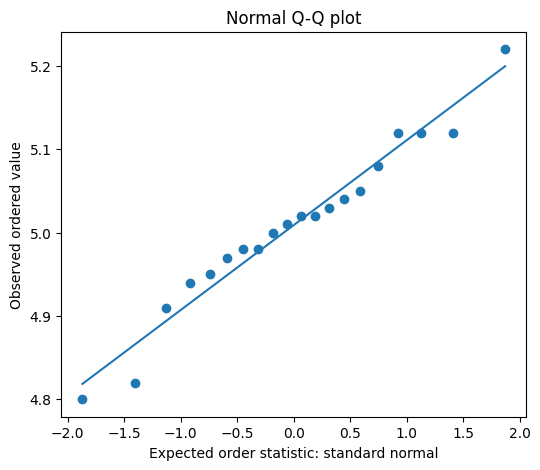

In [15]:
plt.figure(figsize=(6, 5))
plt.scatter(q, y)
plt.plot(q, a + b * q)
plt.xlabel("Expected order statistic: standard normal")
plt.ylabel("Observed ordered value")
plt.title("Normal Q-Q plot")
plt.show()

The plot is roughly straight, which is consistent with the data being approximately normal.

The slope is an estimate of the standard deviation. The intercept is an estimate of the mean.

## 7. What happens if we assume the wrong distribution?

The sample above was designed to look normal. What if we compare it against an exponential distribution?

An exponential distribution is skewed. Its expected sorted pattern is different from a normal distribution's expected sorted pattern.

A wrong distributional assumption often appears as curvature in the Q-Q plot.

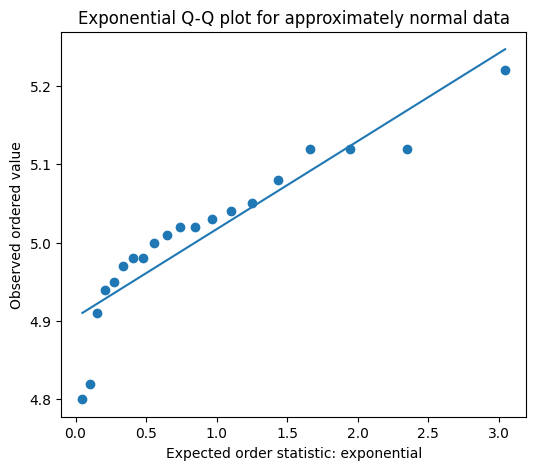

In [16]:
def qq_data_exponential(values):
    values = np.sort(np.asarray(values))
    N = len(values)
    i = np.arange(1, N + 1)
    p = i / (N + 1)
    q = np.array([exp_ppf(pi) for pi in p])
    return q, values, p

eq, ey, ep = qq_data_exponential(sample)
eb, ea = np.polyfit(eq, ey, deg=1)

plt.figure(figsize=(6, 5))
plt.scatter(eq, ey)
plt.plot(eq, ea + eb * eq)
plt.xlabel("Expected order statistic: exponential")
plt.ylabel("Observed ordered value")
plt.title("Exponential Q-Q plot for approximately normal data")
plt.show()

The curve indicates that the exponential model is a poor fit.

This is the practical use of order-statistic plots:

- straight-ish line: proposed distribution is plausible;
- strong curve: proposed distribution is likely wrong;
- isolated bad point: possible outlier or mixed population.

## 8. Example: detecting one foreign observation

Suppose 19 observations come from one normal population, but one observation comes from a shifted population.

This is a non-homogeneous sample. A Q-Q plot often exposes the foreign value as a point that breaks away from the line.

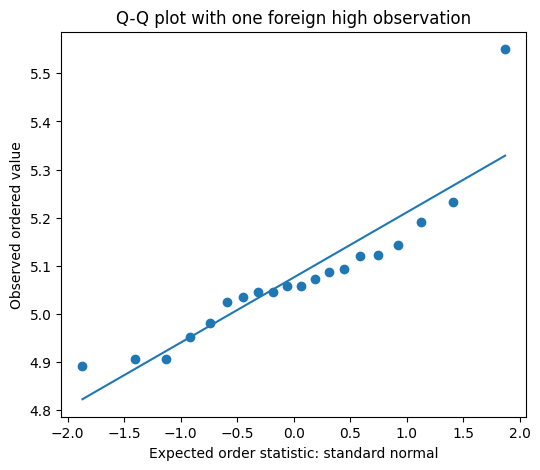

,ordered_value,expected_normal_quantile
15,5.121745,0.744143
16,5.143441,0.919136
17,5.190393,1.128144
18,5.231864,1.403413
19,5.550000,1.868242


In [17]:
mostly_normal = rng.normal(loc=5.0, scale=0.1, size=19)
foreign = np.array([5.55])
contaminated = np.concatenate([mostly_normal, foreign])

q2, y2, p2 = qq_data_normal(contaminated, method="blom")
b2, a2 = np.polyfit(q2, y2, deg=1)

plt.figure(figsize=(6, 5))
plt.scatter(q2, y2)
plt.plot(q2, a2 + b2 * q2)
plt.xlabel("Expected order statistic: standard normal")
plt.ylabel("Observed ordered value")
plt.title("Q-Q plot with one foreign high observation")
plt.show()

pd.DataFrame({
    "ordered_value": np.sort(contaminated),
    "expected_normal_quantile": q2,
}).tail()

The largest observation is too high relative to the straight-line pattern.

The important point is not merely that it is far from the average. Extremes are expected to be far from the average. The issue is that it is far from where the largest value should be according to the pattern of the rest of the sample.

## 9. Applying this to benchmark design

For VM/storage benchmarks, define each condition as a separate population.

| Scenario | Homogeneous if repeated consistently? |
|---|---|
| start VM, immediately randwrite | yes, if every run follows this exactly |
| start VM, randread warmup, then randwrite | yes, if every run follows this exactly |
| random mixture of cold and warmed randwrite | no |
| sometimes same host, sometimes different host | usually no, unless host is a modeled factor |
| sometimes object-store cache warm, sometimes cold | usually no |
| before and after background fetch completes | no, unless separated or modeled |

A good benchmark report should make the state explicit.

In [18]:
runs_per_condition = 10

cold_runs = rng.normal(loc=70, scale=8, size=runs_per_condition)
warm_runs = rng.normal(loc=500, scale=30, size=runs_per_condition)

bench = pd.DataFrame({
    "condition": ["cold"] * runs_per_condition + ["read-warmed"] * runs_per_condition,
    "throughput_mib_s": np.concatenate([cold_runs, warm_runs]),
})

bench.groupby("condition")["throughput_mib_s"].agg(["count", "mean", "std"])

,count,mean,std
condition,,,
cold,10,73.159153,9.099604
read-warmed,10,510.554646,39.982998


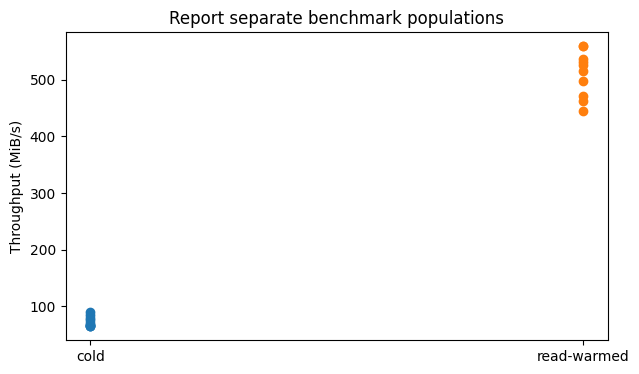

In [19]:
plt.figure(figsize=(7, 4))
positions = {"cold": 1, "read-warmed": 2}
for condition, group in bench.groupby("condition"):
    x_pos = np.full(len(group), positions[condition])
    plt.scatter(x_pos, group["throughput_mib_s"])
plt.xticks([1, 2], ["cold", "read-warmed"])
plt.ylabel("Throughput (MiB/s)")
plt.title("Report separate benchmark populations")
plt.show()

## 10. Checklist for your randwrite benchmark

A careful procedure would look like this.

### Cold randwrite

```text
for each repetition:
    create VM
    wait fixed amount of time, or no wait
    run randwrite benchmark
    record result
    destroy VM
```

### Read-warmed randwrite

```text
for each repetition:
    create VM
    wait fixed amount of time, or no wait
    run fixed randread warmup
    run randwrite benchmark
    record randwrite result
    destroy VM
```

### Report

```text
cold randwrite:
    mean, std, min, max, confidence interval if useful

read-warmed randwrite:
    mean, std, min, max, confidence interval if useful
```

Do not average cold and warmed runs into one number.

## 11. Summary

The core ideas:

1. A homogeneous set behaves like draws from one stable population.
2. Control charts help detect time-order problems: drift, cycles, shifts.
3. Order statistics are sorted observations.
4. The expected cumulative area before the \(i\)-th order statistic is \(i/(N+1)\).
5. The expected x-axis position is not generally \(F^{-1}(i/(N+1))\).
6. Normal probability plots compare sorted observations with expected normal quantiles.
7. A straight Q-Q plot supports the proposed distribution.
8. Curvature suggests wrong distributional shape.
9. Isolated deviations suggest outliers or mixed populations.
10. For benchmarks, cold and warmed states are different experimental conditions and should be measured separately.